[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-biology/AdvancesMSDataProcessing/blob/master/MultivariateExploratoryAnalysisSupervisedModelsClassificationPrediction/Stats_Untargeted_Metabolomics_python.ipynb)


# Performing basic uni- and multivariate statistical analsysis of untargeted metabolomics data

**Updated on:** 2024-02-17 17:33 CET

In this Jupyter Notebook we perform basic explorative uni- and multivariate statistical analyses of an untargeted metabolomics data set, including data cleaning steps, normalization and batch correction. **All step numbers in the Python Notebook correspond to those in the R Notebook to ensure consistency and comparability with the main protocol, which primarily uses the R Notebook.**

<div class="alert alert-block alert-info">

**Authors**: Abzer Kelminal (abzer.shah@uni-tuebingen.de), Francesco Russo (frru@ssi.dk), Filip Ottosson (faot@ssi.dk), Madaleine Ernst (maet@ssi.dk), Axel Walter (axel.walter@uni-tuebingen.de), Carolina Gonzalez (cgonzalez7@eafit.edu.co), Efi Kontou (eeko@biosustain.dtu.dk), Judith Boldt (judith.boldt@dsmz.de) <br>

**Input file format**: .csv files or .txt files <br>
**Outputs**: .csv files, .pdf & .svg images  <br>
**Dependencies**: pandas, numpy, glob, os, re, itertools, plotly, matplotlib, scipy, sklearn, pingouin, skbio, ipyfilechooser, ipywidgets, pynmranalysis, PyComplexHeatmap

The session info at the end of this notebook gives info about the versions of all the packages used here.
</div>

---
<font color = 'red' size =4>**Disclaimer**: This Notebook is compatible with both Jupyter Notebook and Google Colab. However, we advise users with a Windows OS to opt for the Colab version due to potential compatibility issues with certain modules when installed locally on Windows. </font>

## Package installation

### <font color ='darkblue'> Step 2: Installing and loading necessary packages </font>
<a id = 'pkg_install'></a>
Before we start, we need to install all packages needed for our analyses and load the installed packages into our session.

In [1]:
# Install libraries that are not preinstalled
!pip install pandas numpy plotly scikit-learn scikit-posthocs pingouin kaleido nbformat session_info PyComplexHeatmap yellowbrick matplotlib

In [2]:
# importing necessary modules
import pandas as pd
import numpy as np

import glob
import os
import re
import itertools
import io
import session_info
import shutil
import warnings
import matplotlib.pyplot as plt
import platform
import math
import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.io as pio

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.spatial import distance
from scipy.stats import lognorm
from scipy.stats import shapiro
from scipy.stats import lognorm
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import pingouin as pg
import scikit_posthocs as sp
from PyComplexHeatmap import *
from yellowbrick.cluster import KElbowVisualizer

from PIL import Image

import statsmodels.api as sm

import time
from sklearn.inspection import permutation_importance

In [3]:
# Get the operating system information
os_info = platform.system()

# Print the operating system
print(f"The operating system is: {os_info}")

The operating system is: Linux


<font color='red' size= 4 > Installing the following module is not a problem in Google Colab (as it is Linux-based) as well as in macOS and Linux-based systems.</font> scikit-bio is not supported for Windows OS.

In [4]:
if os != "Windows":
    !pip install scikit-bio
    import skbio
    from skbio.stats.distance import permdisp
    print('You can compute PCoA and PERMANOVA')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 58.9 MB/s eta 0:00:00
You can compute PCoA and PERMANOVA


In [5]:
# Disable warnings for cleaner output, comment out for debugging
warnings.filterwarnings('ignore')

# <font color ='blue'> Univariate Analysis </font>
<a id="uni"></a>

### <font color ='darkblue'>Install Packages for Univariate Analyses (already addressed) </font>

No packages need to be installed.

<p style='text-align: justify;'>Univariate statistics involves analysing "one" variable (or one category) at a time in an attempt to describe the data. In univariate statistics, our null hypothesis H0 states that there is no relationship between different groups or categories. To test this hypothesis, we use statistical tests to either reject (meaning there is a relationship between groups) or accept the null hypothesis (means no relationship). Below here is a list of some parametric and non-parametric tests used for hypothesis testing. In general, parametric test assumes the data to have a normal distribution whereas non-parametric tests have no such assumption about the distribution of the data. </p>

<table>
    <thead>
        <tr><th><font size=3>Parametric Test</font></th>
            <th><font size=3>Non-Parametric test</font></th>
        </tr>
    </thead>
    <tbody>
        <tr><td><font size=3>Paired t-test</font></td>
            <td><font size=3>Wilcoxon Rank sum test</font></td></tr>
        <tr><td><font size=3>Unpaired t-test</font></td>
            <td><font size=3>Mann Whitney U-test</font></td></tr>
        <tr><td><font size=3>One-way ANOVA</font></td>
            <td><font size=3>Kruskal Wallis Test</font></td></tr>
    </tbody>
</table>

In the following section we will use univariate statistical analyses to investigate how the metabolome is influenced by:
*   Sampling site: We will compare seven different sampling areas and investigate if there is a gradual shift in metabolite levels from along the coast.
*   Heavy rainfall: We will compare the metabolite levels before and and after a heavy rainfall in January 2018.

---
## Test for normality
<a name="norm_test"></a>

In order to decide whether to go for parametric or non-parametric tests, we test for normality. Some common methods to test for normality are:
1. Visual representations like histogram, Q–Q Plot
2. Statistical tests such as Shapiro–Wilk test, Kolmogorov–Smirnov test

The null hypothosis(H0) of these statistical tests states that the data has a normal distribution. H0= TRUE if p > 0.05. <a href="https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6350423/">Read more about normality tests</a>

Let's start by inspecting the first feature in the dataset:

### <font color ='darkblue'>Normality Testing for One Feature </font>

In [8]:
cleaned_data_with_md = pd.read_csv("Cleaned_table_with_metadata.csv", index_col=0)
cleaned_data_with_md.head()

,ATTRIBUTE_Sample_Type,ATTRIBUTE_Batch,ATTRIBUTE_Month,ATTRIBUTE_Year,ATTRIBUTE_Sample_Location,ATTRIBUTE_Replicate,ATTRIBUTE_Spot,ATTRIBUTE_Latitude,ATTRIBUTE_Longitude,ATTRIBUTE_Sample_Area,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,Sample,2,Jan,2018,10,a,10,32.86261,-117.26042,SIO_La_Jolla_Shores,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,Sample,2,Jan,2018,10,b,10,32.86261,-117.26042,SIO_La_Jolla_Shores,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224
SD_01-2018_11_a.mzXML,Sample,2,Jan,2018,11,a,11,32.85601,-117.26253,SIO_La_Jolla_Shores,...,-0.251313,-0.307305,-1.541638,0.097061,-0.383222,-0.421790,-0.250336,-0.114446,-0.113095,-0.392102
SD_01-2018_11_b.mzXML,Sample,2,Jan,2018,11,b,11,32.85601,-117.26253,SIO_La_Jolla_Shores,...,-0.396538,-0.310075,-1.220736,-0.301133,-0.424088,-0.409242,-0.345876,0.171960,-0.279472,-0.353041
SD_01-2018_12_a.mzXML,Sample,2,Jan,2018,12,a,12,32.85161,-117.26965,La_Jolla_Cove,...,-0.425236,-0.305349,-0.228593,-0.373532,-0.428446,-0.480693,-0.629134,-0.088028,-0.234043,-0.403290


In [9]:
#getting 'cleaned_data_with_md' and selecting all columns that starts with X into the 'norm_test'
norm_test = cleaned_data_with_md.loc[:, cleaned_data_with_md.columns.str.startswith('X')]
norm_test.iloc[:, 0]

SD_01-2018_10_a.mzXML   -0.342852
SD_01-2018_10_b.mzXML   -0.327681
SD_01-2018_11_a.mzXML   -0.314556
SD_01-2018_11_b.mzXML   -0.331714
SD_01-2018_12_a.mzXML   -0.323948
                           ...   
SD_12-2017_7_b.mzXML    -0.350498
SD_12-2017_8_a.mzXML    -0.334002
SD_12-2017_8_b.mzXML    -0.338096
SD_12-2017_9_a.mzXML    -0.315338
SD_12-2017_9_b.mzXML    -0.350197
Name: X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one, Length: 180, dtype: float64

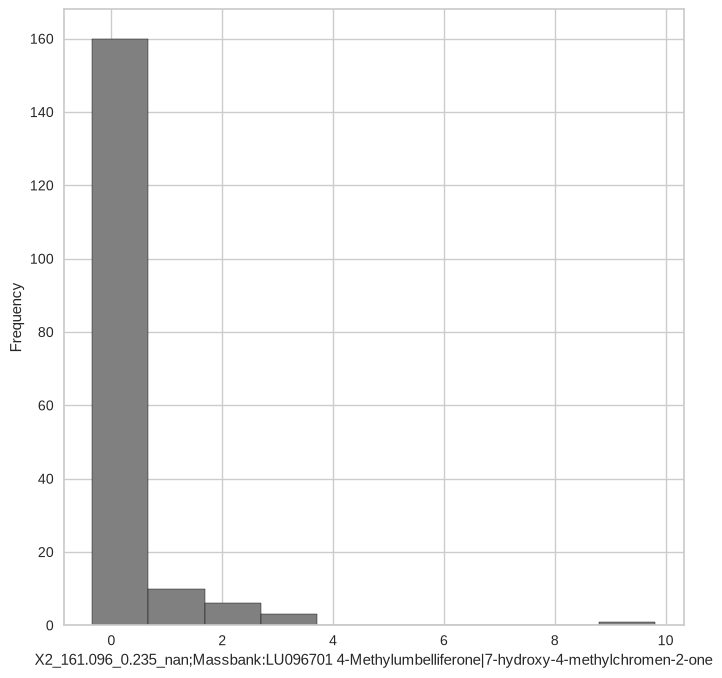

In [10]:
plt.figure(figsize=(8, 8)) # Set the figure size

plt.hist(norm_test.iloc[:, 0], facecolor='grey', ec="black")
plt.xlabel(norm_test.iloc[:, 0].name)
plt.ylabel('Frequency')
plt.show()

**Visualization:** We can also visualize the same using a quantile-quantile plot (Q-Q plot), which plots the observed sample distribution against a theoretical normal distribution.  For ex: In our case, the length of <code>norm_test[,1]</code> is 180. There are 180 samples (or datapoints) for that particular feature. In a Q-Q plot, we first sort these 180 datapoints and then calculate the quantile for each datapoint. The quantile of a datapoint will describe the number of datapoints that falls under that particular datapoint with respect to total number of datapoints. Then these sample quantiles are plotted against the quantiles obtained using a standard normal distribution. With a Q-Q plot, we can visually see how much a particular feature varies from normality, but it is very subjective.

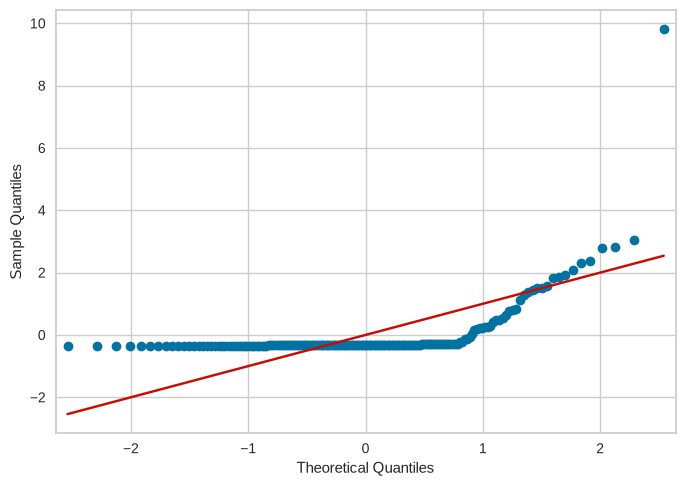

In [11]:
sm.qqplot(norm_test.iloc[:,0], line="s") #add the line with theoretic normal distribution

plt.show()

<b>Interpretation: </b> The plot indicates that the particular feature follows a non-normal distribution. This is subjective. We can also perform a Shapiro-Wilk test on this feature to assess the normality. Here, H0 states that the data has a normal distribution. In a Shapiro-Wilk test, when W=1, it means H0 is true. Also, H0=TRUE when p > 0.05. Howver, in most cases, it is common to have W<1. To see how different the observed distribution from the "empirical" normal distribution, we can look at the p-value.

In [12]:
#perform Shapiro-Wilk test for normality
shapiro(norm_test.iloc[:,0])

ShapiroResult(statistic=np.float64(0.37267044065209864), pvalue=np.float64(1.2409464500806181e-24))

In our case, p<0.05 indicates that the variable follows a non-normal distribution. We can now systematically investigate all metabolite features in the dataset for normality:

We can repeat the same steps and test it on a <b>log-transformed data</b>:

In [13]:
imputed_log= np.log(imp) #transposing the imputed table

plt.figure(figsize=(8, 8)) # Set the figure size

# Histogram
plt.hist(imputed_log.iloc[:,0], facecolor='grey', ec="black") # plot histogram of the first feature
plt.xlabel(imputed_log.iloc[:,0].name)
plt.ylabel('Frequency')
plt.show()


# QQ Plot
fig = plt.figure(figsize=(8, 8))  # Create a figure object first
ax = fig.add_subplot(111)
sm.qqplot(imputed_log.iloc[:,0], line="s", ax= ax) # plot the Q-Q plot
plt.show()

NameError: name 'imp' is not defined

In [ ]:
#perform Shapiro-Wilk test for normality
shapiro(imputed_log.iloc[:,0])

ShapiroResult(statistic=0.9089839458465576, pvalue=4.1989718368995455e-09)

Here, from the qqplot and histogram, one can see that log-transformed data is close to normality than the scaled data that was used before.

### <font color ='darkblue'> Step 59: Normality Testing for All Features </font>

Next, we perform shapiro test on each feature and obtain their p-values. These p-values are then corrected for false discovery rate using BH (Benjamini & Hochberg) correction method. When the significance level of p_adj < 0.05, it rejects H0, thus it will be counted as a non-normal distribution, else it follows normal distribution.

In [14]:
norm_test.copy().head()

,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,X4_167.154_0.474_,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X15_289.168_0.501_,X16_291.165_0.501_,X17_453.234_0.503_,X19_451.237_0.503_,X21_534.268_0.503_,X35_192.062_0.547_,X39_153.033_0.55_,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,-0.342852,-0.594422,0.770878,-0.698076,-0.688803,-0.544895,-0.545050,-0.579735,0.964910,0.498183,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,-0.327681,-0.594734,0.950660,-0.707899,-0.666675,-0.558067,-0.601093,-0.587369,2.198253,1.300497,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224
SD_01-2018_11_a.mzXML,-0.314556,-0.595108,0.550822,-0.229065,-0.214096,-0.593805,-0.538419,-0.594442,0.640314,-0.080669,...,-0.251313,-0.307305,-1.541638,0.097061,-0.383222,-0.421790,-0.250336,-0.114446,-0.113095,-0.392102
SD_01-2018_11_b.mzXML,-0.331714,-0.616160,0.734658,-0.657409,-0.650143,-0.595647,-0.528789,-0.563008,0.347893,-0.180115,...,-0.396538,-0.310075,-1.220736,-0.301133,-0.424088,-0.409242,-0.345876,0.171960,-0.279472,-0.353041
SD_01-2018_12_a.mzXML,-0.323948,-0.612324,0.596451,-0.503381,-0.551075,-0.551527,-0.497215,-0.574347,0.892233,0.792508,...,-0.425236,-0.305349,-0.228593,-0.373532,-0.428446,-0.480693,-0.629134,-0.088028,-0.234043,-0.403290


In [15]:
uni_data= norm_test.copy()
op_shapiro = pd.DataFrame(uni_data.columns) # Get all column to a dataframe called "op_shapiro"
op_shapiro.rename(columns={ op_shapiro.columns[0]: "Metabolites" }, inplace = True) # Convert row "Metabolites" to header and remove the row
op_shapiro

,Metabolites
0,X2_161.096_0.235_nan;Massbank:LU096701 4-Methy...
1,X4_167.154_0.474_
2,"X11_172.956_0.487_nan;""6-methoxypurine, oxamet..."
3,X15_289.168_0.501_
4,X16_291.165_0.501_
...,...
9087,X92603_322.237_13.768_
9088,X92606_172.956_13.801_
9089,X92610_184.985_13.892_nan;4-((hydroxyimino)met...
9090,X92619_264.144_14.118_


In [16]:
pd.set_option('display.max_colwidth', None)
display(op_shapiro)

,Metabolites
0,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one
1,X4_167.154_0.474_
2,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040"""
3,X15_289.168_0.501_
4,X16_291.165_0.501_
...,...
9087,X92603_322.237_13.768_
9088,X92606_172.956_13.801_
9089,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040
9090,X92619_264.144_14.118_


In [17]:
# Compute Shapiro-Wilk test for each column
p_values = []
for col in uni_data.columns:
    _, p_value = shapiro(uni_data[col])
    p_values.append(p_value)

p_adjusted = sm.stats.fdrcorrection(p_values)[1]
op_shapiro['p_adj'] = p_adjusted #adding a column "p_adj" with corrected p-values. The method used is FDR
op_shapiro['p_adj'] = op_shapiro['p_adj'].astype(float)
op_shapiro

,Metabolites,p_adj
0,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,5.557973e-24
1,X4_167.154_0.474_,2.692108e-18
2,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",3.597891e-11
3,X15_289.168_0.501_,5.169173e-16
4,X16_291.165_0.501_,3.054625e-16
...,...,...
9087,X92603_322.237_13.768_,6.155890e-21
9088,X92606_172.956_13.801_,3.567956e-13
9089,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,1.495903e-26
9090,X92619_264.144_14.118_,1.081458e-15


In [18]:
# Classify distributions as normal or non-normal based on adjusted p-values
op_shapiro['distribution'] = ['Normal' if p_adj >= 0.05 else 'Non-normal' for p_adj in op_shapiro['p_adj']]

# Compute and print number of features with normal and non-normal distribution
num_normal = sum(op_shapiro['distribution'] == 'Normal')
num_non_normal = sum(op_shapiro['distribution'] == 'Non-normal')
print("No. of features with normal distribution:", num_normal)
print("No. of features with non-normal distribution:", num_non_normal)

No. of features with normal distribution: 54
No. of features with non-normal distribution: 9038


This shows that the majority of the features have a non-normal distribution. Thus non-parametric tests might make more sense to our data. These normality tests are particularly more useful for small dataset. When your sample size is large, one can still perform the paramteric tests.

In [19]:
# Save the values
op_shapiro.to_csv('Normality_test_results.csv')

---
## ANOVA
<a name="anova"></a>

<p style='text-align: justify;'> We can also perform the parametric test, ANOVA (Analysis of Variance) on our data. Here, we will test whether metabolite levels were different between different sampling sites. Here, the seven different sampling areas will be compared. We  use the function 'aov' to run statistical analyses using ANOVA. ANOVA makes use of variances of different groups to see if they are different from each other. (Variance = SD<sup>2</sup>) </p>
<p style='text-align: justify;'>
<b>H0 = No differences among the groups (their means or Standard deviations)</b>.Using p-value, one can see if the groups are statistically different from one another. When there is a significant difference, F-ratio, another output of ANOVA will be larger and H0 will be rejected. </p>

$$F-statistic = \frac{\text{between-group variance}}{\text{within groups variance}}$$

### <font color ='darkblue'>  Running ANOVA on one feature </font>

In [21]:
def InsideLevels(df):
    # get all the columns (equals all attributes) -> will be number of rows
    levels = []
    types = []
    count = []
    for col in df.columns:
        types.append(type(df[col][0]))
        levels.append(sorted(set(df[col].dropna())))
        tmp = df[col].value_counts()
        count.append([tmp[levels[-1][i]] for i in range(len(levels[-1]))])
    return pd.DataFrame({"ATTRIBUTES": df.columns, "LEVELS": levels, "COUNT":count, "TYPES": types}, index=range(1, len(levels)+1))

In [ ]:
InsideLevels(cleaned_data_with_md.iloc[:, 1:].filter(regex='^(?!X)'))

<font color="red" size="4">Based on the summary table provided above, please input the name of the attribute you wish to use for the ANOVA analysis in the cell below.</font>

In [23]:
# select an attribute to perform ANOVA
anova_attribute = 'ATTRIBUTE_Sample_Area'

In [24]:
print(uni_data.columns[0])
pg.anova(cleaned_data_with_md, uni_data.columns[0], anova_attribute, detailed=True)

X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one


,Source,SS,DF,MS,F,p_unc,np2
0,ATTRIBUTE_Sample_Area,10.78791,6,1.797985,1.838234,0.094279,0.059933
1,Within,169.21209,173,0.978105,NaN,NaN,NaN


The meaning for the terms are as follows:  
'Source': Factor names  
'SS': Sums of squares  
'DF': Degrees of freedom  
'MS': Mean squares  
'F': F-statistic  
'p-unc': uncorrected p-values  
'np2': Partial eta-square effect sizes  

A p value > 0.05 indicates that there is no significant difference for that feature among different groups (in our example, different sample areas).

### <font color ='darkblue'>  Running ANOVA on all features</font>

In [27]:
## defining a function to generate anova data for all features:

def gen_anova_data(df, columns, groups_col):

    results = []

    for col in columns:
        result = pg.anova(data=df, dv=col, between=groups_col, detailed=True).set_index('Source')
        p = result.loc[groups_col, 'p_unc']
        f = result.loc[groups_col, 'F']
        meansq = result.loc[groups_col, 'MS']
        significance = 'Significant' if p < 0.05 else 'Non-significant'

        results.append([col, p, f, meansq, significance])
        anova_columns = ['metabolite', 'p', 'F', 'MS', 'Significance']


    return pd.DataFrame(results, columns=anova_columns)

The above function performs anova tests for all metabolites in the given feature table.

The input arguments:
- `df`: The dataframe which contains the feature intensity information and metadata attributes
- `columns`: A string of all feature names for which anova needs to be performed
- `anova_attribute`: The metadata attribute which contains the group information to perform anova

Returns:  
A dataframe with columns: 'metabolite', 'p', 'F', 'MS', 'Significance'

In [28]:
anova = gen_anova_data(cleaned_data_with_md, uni_data.columns, anova_attribute)
anova

,metabolite,p,F,MS,Significance
0,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,0.094279,1.838234,1.797985,Non-significant
1,X4_167.154_0.474_,0.567786,0.804353,0.814186,Non-significant
2,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",0.353409,1.118602,1.120397,Non-significant
3,X15_289.168_0.501_,0.314193,1.189249,1.188354,Non-significant
4,X16_291.165_0.501_,0.319167,1.179930,1.179409,Non-significant
...,...,...,...,...,...
9087,X92603_322.237_13.768_,0.000014,5.860507,5.067621,Significant
9088,X92606_172.956_13.801_,0.009315,2.940343,2.776206,Significant
9089,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,0.499353,0.895727,0.903891,Non-significant
9090,X92619_264.144_14.118_,0.307968,1.201070,1.199694,Non-significant


In [29]:
# Add Benjamini-Hochberg corrected p-values for multiple testing correction
if 'p_fdr_bh' not in anova.columns:
    anova.insert(2, 'p_fdr_bh', pg.multicomp(anova['p'], method='fdr_bh')[1])

# Add significance based on the corrected p-values
if 'significant' not in anova.columns:
    anova.insert(3, 'significant', anova['p_fdr_bh'] < 0.05)

# Sort by p-value
anova.sort_values('p_fdr_bh', inplace=True)

# save ANOVA table
anova.to_csv(f"ANOVA_results{anova_attribute}.csv")
anova

,metabolite,p,p_fdr_bh,significant,F,MS,Significance
4743,X59188_312.231_7.625_,9.366301e-30,8.515840e-26,True,39.007357,17.249540,Significant
2607,X33200_260.196_4.886_,1.561316e-28,7.097744e-25,True,36.798742,16.820469,Significant
4514,X57080_314.247_7.36_,3.035420e-24,9.199346e-21,True,29.583127,15.192530,Significant
1904,X21870_246.18_3.969_,6.931269e-23,1.575477e-19,True,27.460604,14.634225,Significant
7233,X80910_243.174_10.41_,1.615165e-21,2.937017e-18,True,25.398481,14.049953,Significant
...,...,...,...,...,...,...,...
3812,X49945_729.432_6.507_,9.994388e-01,9.998999e-01,False,0.051392,0.053376,Non-significant
3552,X47359_365.219_6.284_,9.998642e-01,9.998999e-01,False,0.031538,0.032778,Non-significant
3973,X51908_729.432_6.783_,9.997676e-01,9.998999e-01,False,0.037911,0.039393,Non-significant
1728,X19113_381.238_3.737_,9.998590e-01,9.998999e-01,False,0.031943,0.033199,Non-significant


### <font color ='darkblue'>Subsetting Significant Features </font>

In [30]:
print("Total no.of features on which ANOVA test was performed:", len(anova))
print("No.of features that showed significant difference:", len(anova[anova["significant"]==True]))
print("No.of features that did not show significant difference:", len(anova[anova["significant"]==False]))

Total no.of features on which ANOVA test was performed: 9092
No.of features that showed significant difference: 3766
No.of features that did not show significant difference: 5326


In [31]:
# collecting the significant features in an array
anova_significant_metabolites = anova[anova["significant"]==True]["metabolite"].to_numpy()
anova_significant_metabolites

array(['X59188_312.231_7.625_', 'X33200_260.196_4.886_',
       'X57080_314.247_7.36_', ..., 'X56156_371.154_7.241_',
       'X39974_281.174_5.605_', 'X82337_593.348_10.568_'],
      shape=(3766,), dtype=object)

These significant features show a significant difference among the different sampling areas. These features can be further investigated with (tukey) post-hoc analysis shown in next section.

### <font color ='darkblue'>Visualize ANOVA Results </font>

<p style='text-align: justify;'> The anova results are sorted after the p value. To see if there any significant findings, we will use a plot to visualize results from the ANOVA, with log(F-Statistic values) on the x-axis and -log(BH corrected p value) on the y-axis. Since there are large differences in the F-Statistic and P-values, it is easier to plot their log values. When displaying the names of the top features in the plot, it can  easily get cluttered if we decide to display too many names. Hence we are showing very few names. </p>

In [34]:
# first plot insignificant features
fig = px.scatter(x=anova[anova['significant'] == False]['F'].apply(np.log),
                y=anova[anova['significant'] == False]['p_fdr_bh'].apply(lambda x: -np.log(x)),
                template='plotly_white', width=600, height=600)
fig.update_traces(marker_color="#696880")

# plot significant features
fig.add_scatter(x=anova[anova['significant']]['F'].apply(np.log),
                y=anova[anova['significant']]['p_fdr_bh'].apply(lambda x: -np.log(x)),
                mode='markers+text',
                text=anova['metabolite'].iloc[:4],
                textposition='top left', textfont=dict(color='#ef553b', size=7), name='significant')

fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                  title={"text":"ANOVA - FEATURE SIGNIFICANCE", 'x':0.5, "font_color":"#3E3D53"},
                  xaxis_title="log(F)", yaxis_title="-log(p)", showlegend=False)

# save fig as pdf
#fig.write_image("plot_ANOVA.pdf", scale=3) # you can use different file types here e.g. svg, png

fig.show()

<p style='text-align: justify;'>The ANOVA only tests if the between-group variance is larger than the within-group variance. Thus, results only show you whether there are groupwise differences in metabolite levels, but do not show you which pair-wise group comparison are driving this difference. This can be furhter explored using Tukey's Honest Significant Difference.</p>

### <font color ='darkblue'>Visualize Top Significant Metabolites </font>

Here, we are visualizing only the top 4 significant metabolites.

In [36]:
# boxplots with top 4 metabolites from ANOVA
for metabolite in anova.sort_values('p_fdr_bh').iloc[:4, 0]:
    fig = px.box(cleaned_data_with_md, x=anova_attribute, y=metabolite, color=anova_attribute)
    fig.update_layout(showlegend=False, title=metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    display(fig)
    # Save the figure with a filename that includes the metabolite name
    file_name = f"plot_ANOVA_significant_metabolite_{metabolite}.pdf"
    #fig.write_image(file_name, scale=3)

For the top four metabolites, Mission bay is the area that drives the difference between sampling sites, with much higher levels.

---

## Tukey's post-hoc test
<a name ="tukey"></a>
As mentioned above, Tukey's post hoc test is a common post-hoc test after a 1-way anova. It also assumes the data to be normally distributed and homoscedastic (having same variances). Once we know that there is a significant difference among different sampling sites, we can use tukey-test to calculate, which features show statistically significant differences between 2 sampling sites.

### <font color ='darkblue'>Perform Tukey HSD for a Significant Feature </font>

In [ ]:
pg.pairwise_tukey(data=cleaned_data_with_md, dv = anova_significant_metabolites[0], between=anova_attribute)

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,La_Jolla Reefs,La_Jolla_Cove,-0.390058,-0.405410,0.015352,0.221664,0.069258,1.000000e+00,0.274997
1,La_Jolla Reefs,Mission_Bay,-0.390058,1.515913,-1.905971,0.156740,-12.160098,7.482903e-14,-1.823771
2,La_Jolla Reefs,Mission_Beach,-0.390058,-0.404035,0.013978,0.191966,0.072813,1.000000e+00,0.258596
3,La_Jolla Reefs,Pacific_Beach,-0.390058,-0.326873,-0.063185,0.221664,-0.285049,9.999551e-01,-0.601657
4,La_Jolla Reefs,SIO_La_Jolla_Shores,-0.390058,-0.403428,0.013371,0.191966,0.069651,1.000000e+00,0.241725
5,La_Jolla Reefs,Torrey_Pines,-0.390058,-0.358522,-0.031536,0.146617,-0.215089,9.999915e-01,-0.241482
6,La_Jolla_Cove,Mission_Bay,-0.405410,1.515913,-1.921323,0.221664,-8.667746,1.393330e-13,-1.482917
7,La_Jolla_Cove,Mission_Beach,-0.405410,-0.404035,-0.001374,0.247827,-0.005546,1.000000e+00,-0.035935
8,La_Jolla_Cove,Pacific_Beach,-0.405410,-0.326873,-0.078537,0.271481,-0.289290,9.999510e-01,-0.575418
9,La_Jolla_Cove,SIO_La_Jolla_Shores,-0.405410,-0.403428,-0.001981,0.247827,-0.007995,1.000000e+00,-0.047695


The Tukey test gives a Pandas dataframe as an output with the following parameters:  
A: Name of first measurement  
B: Name of second measurement  
mean(A): Mean of first measurement  
mean(B): Mean of second measurement  
diff: Mean difference (= mean(A) - mean(B))  
se: Standard error  
T: T-statistic value  
p-tukey: Tukey-HSD corrected p-values  
hedges: Hedges effect size (or any effect size defined in effsize)

Here, every possible pair-wise group difference is explored. From ANOVA results, since Mission Bay seemed to differ from other sampling sites for the four most significant metabolites, we could specifically look at the results from comparison between Mission Bay and another sampling site.

### <font color ='darkblue'> Step 66: Perform Tukey HSD for all Significant Features </font>

In the code below, we look at the differences between <b> Mission Bay and La Jolla Reefs</b>. We take the anova models that shows significant difference among samplig sites and perform tukey test on only those models.

In [ ]:
def tukey_post_hoc_test(df, anova_attribute, contrasts, metabolites):

    # Ensure metabolites is a list
    metabolites = [metabolites] if isinstance(metabolites, str) else metabolites

    results = []
    for metabolite in metabolites:
        for contrast in contrasts:
            filtered_df = df[df[anova_attribute].isin(contrast)][[metabolite, anova_attribute]]
            pairwise_tukey = pg.pairwise_tukey(filtered_df, dv=metabolite, between=anova_attribute)

            # Getting the order from Tukey result
            group_A = pairwise_tukey['A'].iloc[0]
            group_B = pairwise_tukey['B'].iloc[0]

            diff_value = pairwise_tukey['diff'].iloc[0]
            p_tukey_value = pairwise_tukey['p-tukey'].iloc[0]

            results.append([f'{group_A}-{group_B}', metabolite, int(metabolite.split('_')[0].replace('X', '')), diff_value, p_tukey_value])

    tukey = pd.DataFrame(results, columns=['contrast', 'stats_metabolite', 'stats_ID', 'stats_diff', 'stats_p'])

    # add Benjamini-Hochberg corrected p-values
    tukey['stats_p_bh'] = pg.multicomp(tukey['stats_p'], method='fdr_bh')[1]

    # add significance
    tukey['stats_significant'] = tukey['stats_p_bh'] < 0.05

    # sort by p-value
    tukey.sort_values('stats_p_bh', inplace=True)

    return tukey


This function performs a Tukey's post-hoc test to determine significant differences between group means for specified metabolites. The test is performed for each combination of contrasts and metabolites provided.

<b>Input Parameters:</b>  

- `df` (`pandas.DataFrame`): The dataframe containing the feature intensity information and metadata attributes.
- `anova_attribute` (`str`): The metadata attribute you used for ANOVA test. This contains the group information used in the Tukey's test.
- `contrasts` (`list` of `tuple`): A list of tuples where each tuple contains two group names to be compared in the Tukey's test.
- `metabolites` (`list` or `str`): List of metabolite feature names (or a single metabolite name as a string) for which the Tukey's test needs to be performed. If a single string is provided, the function will convert it to a list.

<b>Returns:</b> Pandas Dataframe containing seven columns:
 - Contrast name in the format as in the Tukey output `group1-group2`.
 - Metabolite name (`stats_metabolite`)
 - Extracted ID from the metabolite name (`stats_ID`).
 - Difference in means between the two groups for the metabolite (`stats-diff`).
 - p-value for the significance of the difference (`stats-p`).
 - BH corrected p-value (`stats_p_bh`)
 - Significance based on the BH corrected p-value (`stats_significant`)

In [ ]:
for value in cleaned_data_with_md[anova_attribute].unique():
    print(value)

SIO_La_Jolla_Shores
La_Jolla_Cove
La_Jolla Reefs
Torrey_Pines
Pacific_Beach
Mission_Beach
Mission_Bay


<font color="red" size="4">The cell above shows the different groups within the `anova_attribute`. For the subsequent Tukey test, please specify the two groups you'd like to compare by entering their names in the next cell.</font>

In [ ]:
group1 = "Mission_Bay"
group2 = "La_Jolla Reefs"

In [ ]:
contrasts = [(group1, group2)]

# Applying the tukey_post_hoc_test function
tukey = tukey_post_hoc_test(df = cleaned_data_with_md,
                            anova_attribute = anova_attribute,
                            contrasts = contrasts,
                            metabolites= anova_significant_metabolites)
tukey.head()

,contrast,stats_metabolite,stats_ID,stats_diff,stats_p,stats_p_bh,stats_significant
0,La_Jolla Reefs-Mission_Bay,X59188_312.231_7.625_nan,59188,-1.905971,3.887168e-11,1.463908e-07,True
24,La_Jolla Reefs-Mission_Bay,X60583_506.326_7.811_nan,60583,-1.670331,2.248162e-10,3.413511e-07,True
1,La_Jolla Reefs-Mission_Bay,X33200_260.196_4.886_nan,33200,-1.834684,2.719207e-10,3.413511e-07,True
2,La_Jolla Reefs-Mission_Bay,X57080_314.247_7.36_nan,57080,-1.781706,3.212070e-09,3.024164e-06,True
15,La_Jolla Reefs-Mission_Bay,X36504_214.191_5.227_nan,36504,-1.722793,4.710073e-09,3.547627e-06,True


In [ ]:
tukey.to_csv(os.path.join(data_dir, f"Tukey_posthoc_test_{group1}_{group2}.csv"), index=False)

### <font color ='darkblue'> Step 67: Count Significant Features </font>

In [ ]:
print("Total no.of features on which ANOVA test was performed:", len(tukey))
print("No.of features that showed significant difference:", len(tukey[tukey["stats_significant"]==True]))
print("No.of features that did not show significant difference:", len(tukey[tukey["stats_significant"]==False]))

Total no.of features on which ANOVA test was performed: 3766
No.of features that showed significant difference: 2815
No.of features that did not show significant difference: 951


### <font color ='darkblue'> Step 68: Visualize Results with a Volcano Plot </font>

Create a volcano plot that displays -log(adj.p.value) on the y-axis and group-difference ('estimate') on the x-axis and display names of top findings in the plot.

In [ ]:
fig = px.scatter(template='plotly_white', width=1000, height=600)

# plot insignificant values
fig.add_trace(go.Scatter(x=tukey[tukey['stats_significant'] == False]['stats_diff'],
                         y=tukey[tukey['stats_significant'] == False]['stats_p'].apply(lambda x: -np.log10(x)),
                         mode='markers', marker_color='#696880', name='insignificant'))

# plot significant values
fig.add_trace(go.Scatter(x=tukey[tukey['stats_significant']]['stats_diff'],
                         y=tukey[tukey['stats_significant']]['stats_p'].apply(lambda x: -np.log10(x)),
                         mode='markers+text', text=anova['metabolite'].iloc[:4], textposition='top left',
                         textfont=dict(color='#ef553b', size=8), marker_color='#ef553b', name='significant'))

# Grabbing the groups from the first contrast
group_A = tukey['contrast'].str.split('-').str[0].iloc[0]
group_B = tukey['contrast'].str.split('-').str[1].iloc[0]

# Add annotations to the figure to indicate upregulated and downregulated groups
fig.add_annotation(
    x=0.85, # Position on x-axis (between 0 and 1)
    y=1.02, # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{group_A} upregulated",
    showarrow=False
)

fig.add_annotation(
    x=0.15, # Position on x-axis (between 0 and 1)
    y=1.02, # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{group_B} upregulated",
    showarrow=False
)

fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                  title={"text":"TUKEY PLOT", 'x':0.5, "font_color":"#3E3D53"},
                  xaxis_title="stats_diff", yaxis_title="-log(p)")

# save image as pdf
fig.write_image(os.path.join(data_dir, "TukeyHSD.pdf"), scale=3)

display(fig)

Similar to ANOVA, we can also visualize the boxplots of the top 2 significant metabolites from both ends of the volcano plot.  
Visualizing the boxplots of the top 2 significant metabolites on the **right tail of the volcano plot**:

In [ ]:
rightside_top_metabolites = tukey[tukey['stats_significant']].sort_values('stats_diff', ascending=False)['stats_metabolite'].iloc[:2]

for stats_metabolite in rightside_top_metabolites:
    fig = px.box(cleaned_data_with_md, x=anova_attribute, y=stats_metabolite, color=anova_attribute)
    fig.update_layout(showlegend=False, title=stats_metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

Visualizing the boxplots of the top 2 significant metabolites on the **left tail of the volcano plot**:

In [ ]:
leftside_top_metabolites = tukey[tukey['stats_significant']].sort_values('stats_diff')['stats_metabolite'].iloc[:2]

for stats_metabolite in leftside_top_metabolites:
    fig = px.box(cleaned_data_with_md, x=anova_attribute, y=stats_metabolite, color=anova_attribute)
    fig.update_layout(showlegend=False, title=stats_metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

---
## T-test
<a name = "t_test"></a>

A T-test is commonly used when one has to compare between only two groups. Here, null hypothesis H0 states no difference between the mean of 2 groups. Similar to the F-statistic used by ANOVA, T-tests use T-statistic.


$$\text{T-statistic} = \frac{\text{Mean}_{\text{group}} - \text{Mean}_{\text{population}}}{\text{SD}_{\text{group}} / \sqrt{\text{group size}}}$$


In our example dataset, we suspect that heavy rainfall in January 2018 could have impacted the metabolome. To investigate this effect, we will conduct t-test, comparing two conditions: 'Jan-2018' and 'not Jan-2018.'

### <font color ='darkblue'> Step 69: Select Attribute for T-test Analysis </font>

In [ ]:
for i in cleaned_data_with_md.iloc[:, 1:].filter(regex='^(?!X)').columns:
    print(i)

ATTRIBUTE_Batch
ATTRIBUTE_Month
ATTRIBUTE_Year
ATTRIBUTE_Sample_Location
ATTRIBUTE_Replicate
ATTRIBUTE_Spot
ATTRIBUTE_Latitude
ATTRIBUTE_Longitude
ATTRIBUTE_Sample_Area
ATTRIBUTE_Spot_Name
ATTRIBUTE_time_run
ATTRIBUTE_Injection_order


<font color = "red" size = 4>For your own dataset, the next step may not be necessary if you already have an attribute with just two groups that you wish to investigate. If your data requires different handling, please modify the code in the following cell to suit your needs. </font>

In [ ]:
ttest_attribute = 'ATTRIBUTE_Month'
target_group = 'Jan'

Here, the 2 conditions for T-test will be 'Jan-2018' or 'not Jan-2018'

### <font color ='darkblue'> Step 70: Perform T-Test </font>

In [ ]:
# Defining a function to generate T-tests:
def gen_ttest_data(df, columns, ttest_attribute, target_group):
    ttest = []
    for col in columns:
        group1 = df[col][df[ttest_attribute]==target_group]
        group2 = df[col][df[ttest_attribute]!=target_group]
        result = pg.ttest(group1, group2)
        result['Metabolite'] = col

        ttest.append(result)

    ttest = pd.concat(ttest).set_index('Metabolite')

    ttest.insert(8, 'p-bh', pg.multicomp(ttest['p-val'], method='fdr_bh')[1])
    # add significance
    ttest.insert(9, 'Significance', ttest['p-bh'] < 0.05)
    ttest.sort_values('p-bh', inplace=True)

    return ttest

The above function performs t-tests for all metabolites in the given feature table.

The input arguments:
- `df`: The dataframe which contains the feature intensity information and metadata attributes
- `columns`: A string of all feature names for which t-test needs to be performed
- `ttest_attribute`: The metadata attribute which contains the group information to perform ttest
- ` target_group`: In case of multiple groups in the attribute, it will converted to binary information such as 'target_group' vs others

Returns:  
A pandas dataframe with columns:  
- 'Metabolite' - Name of the metabolite
- 'T': T-value
- 'dof': degrees of freedom
- 'alternative': alternative of the test
- 'p-val': p-value
- 'CI95%': confidence intervals of the difference in means
- 'cohen-d': Cohen d effect size
- 'BF10': Bayes Factor of the alternative hypothesis
- 'power': achieved power of the test ( = 1 - type II error)
- 'p-bh' : BH-corrected P values
- 'Significance': Significance value based on BH-corrected P values

In [ ]:
ttest = gen_ttest_data(cleaned_data_with_md, uni_data.columns, ttest_attribute, target_group)
ttest.head(5)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,p-bh,Significance
Metabolite,,,,,,,,,,
X2716_252.123_1.231_nan,36.589039,177.124398,two-sided,1.696687e-84,"[1.83, 2.04]",4.638502,5.035e+80,1.0,1.542628e-80,True
X4504_301.175_2.04_nan,37.115591,171.392814,two-sided,7.579158e-84,"[1.85, 2.06]",5.020727,4.696e+81,1.0,3.445485e-80,True
X61401_256.19_7.915_nan;methyl (Z)-tetradec-9-enoate,34.805929,110.724492,two-sided,1.861203e-61,"[1.87, 2.1]",5.639910,2.174e+77,1.0,5.640685e-58,True
X44803_456.274_5.953_nan,-23.615073,177.940686,two-sided,9.921470e-57,"[-1.89, -1.6]",3.029967,8.928e+52,1.0,2.255150e-53,True
X68756_402.3_8.994_nan,-22.373376,156.883216,two-sided,1.118439e-50,"[-1.81, -1.52]",2.661878,7.17e+49,1.0,2.033769e-47,True


In [ ]:
ttest.to_csv(os.path.join(data_dir, f"ttest_results_{ttest_attribute}_target_group_{target_group}.csv"))

### <font color ='darkblue'> Step 71: Plot T-Test Results </font>

In [ ]:
# To avoid taking -log10(0)
ttest['log_p'] = ttest['p-bh'].apply(lambda x: -np.log10(x + 1e-50))

fig = px.scatter(template='plotly_white', width=1000, height=600)

# Plot insignificant values
fig.add_trace(go.Scatter(x=ttest[ttest['Significance'] == False]['T'],
                         y=ttest[ttest['Significance'] == False]['log_p'],
                         mode='markers', marker_color='#696880', name='insignificant'))

# Plot significant values
fig.add_trace(go.Scatter(x=ttest[ttest['Significance']]['T'],
                         y=ttest[ttest['Significance']]['log_p'],
                         mode='markers+text', text=ttest.index[:4], textposition='top left',
                         textfont=dict(color='#ef553b', size=8), marker_color='#ef553b', name='significant'))

fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                  title={"text":"T-TEST VOLCANO PLOT", 'x':0.5, "font_color":"#3E3D53"},
                  xaxis_title="T-statistic", yaxis_title="-log(p)")

# Adding annotations
fig.add_annotation(
    x=0.85,  # Position on x-axis (between 0 and 1)
    y=1.02,  # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{target_group} upregulated",
    showarrow=False,
    font=dict(size=12, color="black")
)

fig.add_annotation(
    x=0.15,  # Position on x-axis (between 0 and 1)
    y=1.02,  # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{target_group} downregulated",
    showarrow=False,
    font=dict(size=12, color="black")
)

# save image as pdf
fig.write_image(os.path.join(data_dir, "T-Test_Volcano_Plot.pdf"), scale=3)

display(fig)


In addition to that, visualizing **the top 2 significant metabolites from the right tail of the volcano plot:**

In [ ]:
rightside_top_metabolites_ttest = ttest[ttest['Significance']].sort_values('T', ascending=False).index[:2]

for metabolite in rightside_top_metabolites_ttest:
    fig = px.box(cleaned_data_with_md, x=ttest_attribute, y=metabolite, color=ttest_attribute)
    fig.update_layout(showlegend=False, title=metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

In addition to that, visualizing **the top 2 significant metabolites from the left tail of the volcano plot:**

In [ ]:
leftside_top_metabolites_ttest = ttest[ttest['Significance']].sort_values('T').index[:2]

for metabolite in leftside_top_metabolites_ttest:
    fig = px.box(cleaned_data_with_md, x=ttest_attribute, y=metabolite, color=ttest_attribute)
    fig.update_layout(showlegend=False, title=metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

---
## Kruskal-Wallis Test
<a name="kr_wallis"></a>

Kruskal-Wallis Test is a non-parametric version of ANOVA. Here, the test does not assume normality of the data. The median of multiple groups are compared to see if they are statistically different from one another. The null hypothesis H0 states no significant difference among different groups. Based on the p value, we decide whether to reject H0 or not. When H0 is rejected, the alternate hypothesis H1 states that atleast one group is statistically different from the others.
<a href="https://statsandr.com/blog/kruskal-wallis-test-nonparametric-version-anova/#introduction">Read more about Kruskal-Wallis test</a>

### <font color ='darkblue'> Step 72: Perform Kruskal-Wallis Test on the first feature </font>

In [ ]:
InsideLevels(cleaned_data_with_md.iloc[:, 1:].filter(regex='^(?!X)'))

,ATTRIBUTES,LEVELS,COUNT,TYPES
1,ATTRIBUTE_Batch,"[1, 2, 3]","[60, 60, 60]",<class 'numpy.int64'>
2,ATTRIBUTE_Month,"[Dec, Jan, Oct]","[60, 60, 60]",<class 'str'>
3,ATTRIBUTE_Year,"[2017, 2018]","[60, 120]",<class 'numpy.int64'>
4,ATTRIBUTE_Sample_Location,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]",<class 'numpy.int64'>
5,ATTRIBUTE_Replicate,"[a, b]","[90, 90]",<class 'str'>
6,ATTRIBUTE_Spot,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]",<class 'numpy.int64'>
7,ATTRIBUTE_Latitude,"[32.75645, 32.75743, 32.75905, 32.76115, 32.7623, 32.76504, 32.76576, 32.77471, 32.78525, 32.7955, 32.80386, 32.81039, 32.81743, 32.82428, 32.83142, 32.84007, 32.84638, 32.85161, 32.85197, 32.85601, 32.86261, 32.86989, 32.87627, 32.88456, 32.89303, 32.90106, 32.91016, 32.91927, 32.92639, 32.93365]","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]",<class 'numpy.float64'>
8,ATTRIBUTE_Longitude,"[-117.2872, -117.28664, -117.286, -117.28355, -117.28343, -117.27733, -117.27703, -117.27325, -117.26965, -117.26497, -117.26483, -117.26452, -117.26446, -117.26265, -117.26253, -117.2622, -117.26188, -117.26068, -117.26059, -117.26042, -117.25929, -117.25879, -117.25866, -117.25836, -117.2557, -117.25317, -117.24785, -117.24467, -117.24051, -117.2363]","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]",<class 'numpy.float64'>
9,ATTRIBUTE_Sample_Area,"[La_Jolla Reefs, La_Jolla_Cove, Mission_Bay, Mission_Beach, Pacific_Beach, SIO_La_Jolla_Shores, Torrey_Pines]","[36, 12, 36, 18, 12, 18, 48]",<class 'str'>
10,ATTRIBUTE_Spot_Name,"[Big_Rock, Blacks_North_Peak, Blacks_South_Peaks, Cove, Horseshoe, Hospitals, La_Jolla_Shores, Lagoon_Outlet, Little_Point, Mariners_Basin, Mission_Bay_Canal, Mission_Beach, Mission_Jetty, North_Bird, PB_Pier, PB_Point, Quivira_Marina, SIO_North_Pier, SIO_South_Pier, South_Bird, Torrey_Pines]","[6, 6, 6, 12, 6, 6, 6, 6, 6, 6, 12, 18, 6, 6, 6, 6, 12, 6, 6, 6, 30]",<class 'str'>


<font color="red" size="4">Based on the summary table provided above, please input the name of the attribute you wish to use for the ANOVA analysis in the cell below.</font> Here, we tried to perfom Kruskal-Wallis test across different sample areas similar to its parametric counterpart, ANOVA.

In [ ]:
# select an attribute to perform Kruskal Wallis
kruskal_attribute = 'ATTRIBUTE_Sample_Area'

In [ ]:
print(uni_data.columns[0])
pg.kruskal(cleaned_data_with_md, uni_data.columns[0], kruskal_attribute, detailed=True)

X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one


,Source,ddof1,H,p-unc
Kruskal,ATTRIBUTE_Sample_Area,6,7.483531,0.278433


The test returns a pandas dataframe with the follwoing columns:  
- 'H': The Kruskal-Wallis H statistic, corrected for ties
- 'p-unc': Uncorrected p-value
- 'ddof1': degrees of freedom

### <font color ='darkblue'>  Step 73: Run Kruskal-Wallis Test for All Features </font>

In [ ]:
## defining a function to perform kruskal-wallis test all features:

def gen_kruskal_data(df, columns, groups_col):
    results = []

    for col in columns:
        result = pg.kruskal(data=df, dv=col, between=groups_col, detailed=True).set_index('Source')
        p = result.loc[groups_col, 'p-unc']
        H = result.loc[groups_col, 'H']
        dof = result.loc[groups_col, 'ddof1']

        results.append([col, int(col.split('_')[0].replace('X', '')), p, H, dof])

    kruskal_columns = ['metabolite', 'stats_ID', 'p', 'H', 'dof']
    kruskal = pd.DataFrame(results, columns=kruskal_columns)

    # add Benjamini-Hochberg corrected p-values
    kruskal['stats_p_bh'] = pg.multicomp(kruskal['p'], method='fdr_bh')[1]

    # add significance
    kruskal['stats_significant'] = kruskal['stats_p_bh'] < 0.05

    # sort by p-value
    kruskal.sort_values('stats_p_bh', inplace=True)

    return kruskal

In [ ]:
kruskal = gen_kruskal_data(cleaned_data_with_md, uni_data.columns, kruskal_attribute)
kruskal.head()

,metabolite,stats_ID,p,H,dof,stats_p_bh,stats_significant
8840,"X91372_906.258_12.697_nan;(3S,4R)-7-hydroxy-3-[(3S,4R)-7-hydroxy-4-(4-hydroxyphenyl)-2-oxo-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-3-yl]-4-(4-hydroxyphenyl)-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-2-one",91372,4.320167e-22,113.216114,6,2.567264e-18,True
8705,"X90743_908.258_12.555_nan;[3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl] 9-(hydroxymethyl)-2,2,6a,6b,9,12a-hexamethyl-10-[3,4,5-trihydroxy-6-[(3,4,5-trihydroxy-6-methyloxan-2-yl)oxymethyl]oxan-2-yl]oxy-1,3,4,5,6,6a,7,8,8a,10,11,12,13,14b-tetradecahydropicene-4a-carboxylate",90743,5.647302e-22,112.661035,6,2.567264e-18,True
8783,X91133_907.259_12.628_nan;THEAFLAVIN DIGALLATE,91133,8.490933e-22,111.815806,6,2.573319e-18,True
8678,"X90597_906.258_12.403_nan;(3S,4R)-7-hydroxy-3-[(3S,4R)-7-hydroxy-4-(4-hydroxyphenyl)-2-oxo-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-3-yl]-4-(4-hydroxyphenyl)-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-2-one",90597,2.624109e-21,109.476092,6,5.964599e-18,True
8992,"X92112_906.258_12.941_nan;(3S,4R)-7-hydroxy-3-[(3S,4R)-7-hydroxy-4-(4-hydroxyphenyl)-2-oxo-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-3-yl]-4-(4-hydroxyphenyl)-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-2-one",92112,1.740542e-20,105.548590,6,3.165001e-17,True


In [ ]:
kruskal.to_csv(os.path.join(data_dir, f"kruskal_results_{kruskal_attribute}.csv"))

### <font color ='darkblue'> Step 74: Filter Significant Features </font>

In [ ]:
print("Total no.of features on which Kruskal-Wallis test was performed:", len(kruskal))
print("No.of features that showed significant difference:", len(kruskal[kruskal["stats_significant"]==True]))
print("No.of features that did not show significant difference:", len(kruskal[kruskal["stats_significant"]==False]))

Total no.of features on which Kruskal-Wallis test was performed: 9092
No.of features that showed significant difference: 1278
No.of features that did not show significant difference: 7814


In [ ]:
# collecting the significant features in an array
kruskal_significant_metabolites = kruskal[kruskal["stats_significant"]==True]["metabolite"].to_numpy()
kruskal_significant_metabolites

array(['X91372_906.258_12.697_nan;(3S,4R)-7-hydroxy-3-[(3S,4R)-7-hydroxy-4-(4-hydroxyphenyl)-2-oxo-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-3-yl]-4-(4-hydroxyphenyl)-5-[(2S,3R,4S,5S,6R)-3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxy-3,4-dihydrochromen-2-one',
       'X90743_908.258_12.555_nan;[3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl] 9-(hydroxymethyl)-2,2,6a,6b,9,12a-hexamethyl-10-[3,4,5-trihydroxy-6-[(3,4,5-trihydroxy-6-methyloxan-2-yl)oxymethyl]oxan-2-yl]oxy-1,3,4,5,6,6a,7,8,8a,10,11,12,13,14b-tetradecahydropicene-4a-carboxylate',
       'X91133_907.259_12.628_nan;THEAFLAVIN DIGALLATE', ...,
       'X88253_700.234_11.593_Contaminant vial septum ThermoFisher C5000-44B',
       'X1325_350.744_0.711_nan', 'X2761_284.206_1.252_nan'], dtype=object)

### <font color ='darkblue'> Step 75: Visualize Kruskal-Wallis Results </font>

In [ ]:
# first plot in significant features
fig = px.scatter(x=kruskal[kruskal['stats_significant'] == False]['H'].apply(np.log),
                y=kruskal[kruskal['stats_significant'] == False]['stats_p_bh'].apply(lambda x: -np.log(x)),
                template='plotly_white', width=600, height=600)
fig.update_traces(marker_color="#696880")

# plot significant features
fig.add_scatter(x=kruskal[kruskal['stats_significant']]['H'].apply(np.log),
                y=kruskal[kruskal['stats_significant']]['stats_p_bh'].apply(lambda x: -np.log(x)),
                mode='markers+text',
                text=kruskal['metabolite'].iloc[:4],
                textposition='top left', textfont=dict(color='#ef553b', size=7), name='significant')

fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                  title={"text":"KRUSKAL-WALLIS TEST - FEATURE SIGNIFICANCE", 'x':0.5, "font_color":"#3E3D53"},
                  xaxis_title="log(H)", yaxis_title="-log(p)", showlegend=False)

# save fig as pdf
fig.write_image(os.path.join(data_dir, "plot_kruskal.pdf"), scale=3) # you can use different file types here e.g. svg, png

fig.show()

### <font color ='darkblue'> Step 76: Visualize Top Significant Metabolites of Kruskal-Wallis Results</font>

In [ ]:
for idx, row in kruskal.sort_values('stats_p_bh').iloc[:4].iterrows():
    metabolite = row['metabolite']
    stats_id = row['stats_ID']
    fig = px.box(cleaned_data_with_md, x=kruskal_attribute, y=metabolite, color=kruskal_attribute)
    fig.update_layout(showlegend=False, title=metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    display(fig)

    # Save the figure with the stats_ID in the filename
    file_name = f"plot_KruskalWallis_significant_metabolite_{stats_id}.pdf"
    fig.write_image(os.path.join(data_dir, file_name), scale=3)

---
## Dunn's post hoc test
<a name ="dunn"></a>

If Kruskal_Wallis test shows there is a significant difference among groups, then we can perform post-hoc test. The most common post-hoc test for Kruskal-Wallis is "Dunn Test" where one can perform multiple pairwise comparison to know exactly which groups are significantly different.
Here, in our example, we use Dunn test to calculate, which features show statistically significant differences between individual sampling sites.

### <font color ='darkblue'> Step 77: Perform Dunn Test for a Significant Feature </font>

In [ ]:
dunn_test_one_feature = sp.posthoc_dunn(a=cleaned_data_with_md, val_col  = kruskal_significant_metabolites[0], group_col =kruskal_attribute, p_adjust='fdr_bh', sort=True)
dunn_test_one_feature

,La_Jolla Reefs,La_Jolla_Cove,Mission_Bay,Mission_Beach,Pacific_Beach,SIO_La_Jolla_Shores,Torrey_Pines
La_Jolla Reefs,1.000000e+00,0.062882,7.358203e-01,4.194062e-01,7.524000e-01,6.980727e-07,7.773518e-16
La_Jolla_Cove,6.288240e-02,1.000000,1.144761e-01,3.501442e-01,2.342792e-01,6.288240e-02,9.515232e-04
Mission_Bay,7.358203e-01,0.114476,1.000000e+00,6.429004e-01,9.540869e-01,3.695907e-06,1.804138e-14
Mission_Beach,4.194062e-01,0.350144,6.429004e-01,1.000000e+00,7.358203e-01,6.356242e-04,9.496747e-08
Pacific_Beach,7.524000e-01,0.234279,9.540869e-01,7.358203e-01,1.000000e+00,5.761750e-04,3.946330e-07
SIO_La_Jolla_Shores,6.980727e-07,0.062882,3.695907e-06,6.356242e-04,5.761750e-04,1.000000e+00,3.158202e-01
Torrey_Pines,7.773518e-16,0.000952,1.804138e-14,9.496747e-08,3.946330e-07,3.158202e-01,1.000000e+00


In [ ]:
# Filter the results to show only significant p-values (e.g., < 0.05)
significant_pvals_df = dunn_test_one_feature.where(dunn_test_one_feature < 0.05)
significant_pvals_df

,La_Jolla Reefs,La_Jolla_Cove,Mission_Bay,Mission_Beach,Pacific_Beach,SIO_La_Jolla_Shores,Torrey_Pines
La_Jolla Reefs,NaN,NaN,NaN,NaN,NaN,6.980727e-07,7.773518e-16
La_Jolla_Cove,NaN,NaN,NaN,NaN,NaN,NaN,9.515232e-04
Mission_Bay,NaN,NaN,NaN,NaN,NaN,3.695907e-06,1.804138e-14
Mission_Beach,NaN,NaN,NaN,NaN,NaN,6.356242e-04,9.496747e-08
Pacific_Beach,NaN,NaN,NaN,NaN,NaN,5.761750e-04,3.946330e-07
SIO_La_Jolla_Shores,6.980727e-07,NaN,3.695907e-06,6.356242e-04,5.761750e-04,NaN,NaN
Torrey_Pines,7.773518e-16,0.000952,1.804138e-14,9.496747e-08,3.946330e-07,NaN,NaN


### <font color ='darkblue'> Step 78: Perform Dunn Test for all Significant Features </font>

In [ ]:
def dunn_post_hoc_test(df, kruskal_attribute, contrasts, metabolites):

    # Ensure metabolites is a list
    metabolites = [metabolites] if isinstance(metabolites, str) else metabolites

    results = []
    for metabolite in metabolites:
        for contrast in contrasts:
            filtered_df = df[df[kruskal_attribute].isin(contrast)][[metabolite, kruskal_attribute]]

            # Conduct Dunn's posthoc test
            dunn_result = sp.posthoc_dunn(a=filtered_df, val_col=metabolite, group_col=kruskal_attribute, p_adjust='fdr_bh', sort=True)
            p_value = dunn_result.loc[contrast[0], contrast[1]]

            # Calculate rank sum differences
            ranks = stats.rankdata(filtered_df[metabolite])
            rank_sum_A = sum(ranks[filtered_df[kruskal_attribute] == contrast[0]])
            rank_sum_B = sum(ranks[filtered_df[kruskal_attribute] == contrast[1]])
            rank_sum_diff = rank_sum_A - rank_sum_B

            results.append([f'{contrast[0]}-{contrast[1]}', metabolite, int(metabolite.split('_')[0].replace('X', '')), rank_sum_diff, p_value])

    dunn_df = pd.DataFrame(results, columns=['contrast', 'stats_metabolite', 'stats_ID', 'rank_sum_diff', 'stats_p_bh'])

    # Add significance
    dunn_df['stats_significant'] = dunn_df['stats_p_bh'] < 0.05

    # Sort by p-value
    dunn_df.sort_values('stats_p_bh', inplace=True)

    return dunn_df

This function performs a Dunn's post-hoc test to determine significant differences between groups for specified metabolites. The test is performed for each combination of contrasts and metabolites provided.

<b>Input Parameters:</b>  

- `df` (`pandas.DataFrame`): The dataframe containing the feature intensity information and metadata attributes.
- `kruskal_attribute` (`str`): The metadata attribute you used for Kruskal-Wallis test.
- `contrasts` (`list` of `tuple`): A list of tuples where each tuple contains two group names to be compared in the Tukey's test.
- `metabolites` (`list` or `str`): List of metabolite feature names (or a single metabolite name as a string) for which the Dunn's test needs to be performed. If a single string is provided, the function will convert it to a list.

<b>Returns:</b> Pandas Dataframe containing seven columns:
 - Contrast name in the format `group1-group2`.
 - Metabolite name (`stats_metabolite`)
 - Extracted ID from the metabolite name (`stats_ID`).
 - Difference in rank sums between the two groups for the metabolite (`rank_sum_diff`).
 - BH corrected p-value for the significance of the difference (`stats_p_bh`).
 - Significance based on the BH corrected p-value (`stats_significant`)

In [ ]:
for value in cleaned_data_with_md[kruskal_attribute].unique():
    print(value)

SIO_La_Jolla_Shores
La_Jolla_Cove
La_Jolla Reefs
Torrey_Pines
Pacific_Beach
Mission_Beach
Mission_Bay


<font color="red" size="4">The cell above shows the different groups within the `kruskal_attribute`. For the subsequent Dunn test, please specify the two groups you'd like to compare by entering their names in the next cell.</font> Here, we wish to look at the comparison between **La Jolla Reefs and Mission Bay.**

In [ ]:
dunn_group1 = "La_Jolla Reefs"
dunn_group2 = "Mission_Bay"

In [ ]:
dunn_contrasts = [(dunn_group1, dunn_group2)]

# Applying the dunn_post_hoc_test function
dunn = dunn_post_hoc_test(df=cleaned_data_with_md,
                          kruskal_attribute = kruskal_attribute,
                          contrasts = dunn_contrasts,
                          metabolites= kruskal_significant_metabolites)

dunn.head()

,contrast,stats_metabolite,stats_ID,rank_sum_diff,stats_p_bh,stats_significant
14,La_Jolla Reefs-Mission_Bay,X59188_312.231_7.625_nan,59188,-1122.0,2.646355e-10,True
19,La_Jolla Reefs-Mission_Bay,X57080_314.247_7.36_nan,57080,-1104.0,5.074479e-10,True
25,La_Jolla Reefs-Mission_Bay,X60583_506.326_7.811_nan,60583,-1096.0,6.754476e-10,True
9,La_Jolla Reefs-Mission_Bay,X54129_381.808_6.99_nan,54129,-1056.0,2.739551e-09,True
23,La_Jolla Reefs-Mission_Bay,X82124_413.268_10.607_nan,82124,-1036.0,5.415761e-09,True


In [ ]:
dunn.to_csv(os.path.join(data_dir, f"Dunn_posthoc_test_{dunn_group1}_{dunn_group2}.csv"), index=False)

### <font color ='darkblue'> Step 79: Count all Significant Features </font>

In [ ]:
print("Total no.of features on which Dunn Test test was performed:", len(dunn))
print("No.of features that showed significant difference:", len(dunn[dunn["stats_significant"]==True]))
print("No.of features that did not show significant difference:", len(dunn[dunn["stats_significant"]==False]))

Total no.of features on which Dunn Test test was performed: 1278
No.of features that showed significant difference: 935
No.of features that did not show significant difference: 343


### <font color ='darkblue'> Step 80: Visualize Results with a Volcano Plot </font>

In [ ]:
fig = px.scatter(template='plotly_white', width=1000, height=600)

# plot insignificant values
fig.add_trace(go.Scatter(x=dunn[dunn['stats_significant'] == False]['rank_sum_diff'],
                         y=dunn[dunn['stats_significant'] == False]['stats_p_bh'].apply(lambda x: -np.log10(x)),
                         mode='markers', marker_color='#696880', name='insignificant'))

# plot significant values
fig.add_trace(go.Scatter(x=dunn[dunn['stats_significant']]['rank_sum_diff'],
                         y=dunn[dunn['stats_significant']]['stats_p_bh'].apply(lambda x: -np.log10(x)),
                         mode='markers+text', text=kruskal['metabolite'].iloc[:4], textposition='top left',
                         textfont=dict(color='#ef553b', size=8), marker_color='#ef553b', name='significant'))

# Grabbing the groups from the first contrast
group_A = dunn['contrast'].str.split('-').str[0].iloc[0]
group_B = dunn['contrast'].str.split('-').str[1].iloc[0]

# Add annotations to the figure to indicate upregulated and downregulated groups
fig.add_annotation(
    x=0.85, # Position on x-axis (between 0 and 1)
    y=1.02, # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{group_A} upregulated",
    showarrow=False
)

fig.add_annotation(
    x=0.15, # Position on x-axis (between 0 and 1)
    y=1.02, # Position on y-axis (between 0 and 1)
    xref="paper",
    yref="paper",
    text=f"{group_B} upregulated",
    showarrow=False
)

fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                  title={"text":"Dunn Test Plot", 'x':0.5, "font_color":"#3E3D53"},
                  xaxis_title="Difference of Rank sums", yaxis_title="-log(p)")

# save image as pdf
fig.write_image(os.path.join(data_dir, "DunnTest.pdf"), scale=3)

display(fig)

Also visualizing the boxplots of the top 2 significant metabolites on the **right tail of the volcano plot**:

In [ ]:
rightside_top_metabolites_dunn = dunn[dunn['stats_significant']].sort_values('rank_sum_diff', ascending=False)['stats_metabolite'].iloc[:2]

for stats_metabolite in rightside_top_metabolites_dunn:
    fig = px.box(cleaned_data_with_md, x=kruskal_attribute, y=stats_metabolite, color=kruskal_attribute)
    fig.update_layout(showlegend=False, title=stats_metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

Visualizing the boxplots of the top 2 significant metabolites on the **left tail of the volcano plot**:

In [ ]:
left_top_metabolites_dunn = dunn[dunn['stats_significant']].sort_values('rank_sum_diff')['stats_metabolite'].iloc[:2]

for stats_metabolite in left_top_metabolites_dunn:
    fig = px.box(cleaned_data_with_md, x=kruskal_attribute, y=stats_metabolite, color=kruskal_attribute)
    fig.update_layout(showlegend=False, title=stats_metabolite, xaxis_title="", yaxis_title="intensity", template="plotly_white", width=500)
    fig.show()

# <font color = 'blue'>  7. Conclusion </font>
<a name="outro"></a>

### Getting output files from Google Colab
Until now, all the files and images saved are within the Colab session and we need to download them. Instead of downloading all the files individually, we can zip the entire folder using the next cell and download only the zip file into the local system. <font color ="red">The zip file can be found in the working directory, in our case, "/content/My_TestData". </font>

In [ ]:
# Only for Google Colab
output_filename = '../TestData_Workflow_Results' # Specify the name and location of the output directory (here it will be in '/content/TestData_Workflow_Results')
dir_input = data_dir # Specify the directory to be zipped (here the Results directory specified in the beginning)
shutil.make_archive(output_filename, 'zip', dir_input)

'/content/TestData_Workflow_Results.zip'

<p style='text-align: justify;'> This concludes all the analyses proposed in this work as essential for metabolomics data processing.  While this workflow serves as a foundational guideline including many key tests, it was primarily constructed with a basic case study perspective and might not include all potential evaluations. Also a significant emphasis has been placed on ensuring this notebook's adaptability. While the examples utilize test data, the notebook is structured to be as flexible as possible, facilitating easy integration and adaptation with your own dataset. </p>

<u>To get the most out of this notebook:</u>
- Read the comments in the code.
- Check the package functions and their documentation if you have any doubt about how each function works and how changing parameters might be appropiate for your particular data.
- If something isn't clear or isn't working, ask for help on our GitHub page. Whether it's a query, a suggestion, or feedback, we value your interaction.

<p style='text-align: justify;'><b>Lastly, if this notebook is used in your research or projects, we kindly ask that you acknowledge our work by citing it as follows:</b></p>

<p style='text-align: justify;'><font color='red'>Pakkir Shah, A.K., Walter, A., Ottosson, F. et al. The Hitchhiker’s Guide to Statistical Analysis of Feature-based Molecular Networks from Non-Targeted Metabolomics Data. <b>ChemRxiv</b> (2023).  https://doi.org/10.26434/chemrxiv-2023-wwbt0 This content is a preprint and has not been peer-reviewed.</font></p>

<p style='text-align: justify;'> Finally, it is important to get the information of the Python session used for running the analyses. The 'Python session' data includes the version of the Python environment and the loaded packages. This information is useful for debugging purposes. If you raise any issues or questions in the GitHub page of this notebook, please, include the session details. It will help us help you better. </p>

To see all the information about the current Python session:

In [ ]:
session_info.show() # To see all the information about the current Python session